In [2]:
import matplotlib.pyplot as plt
import numpy as np

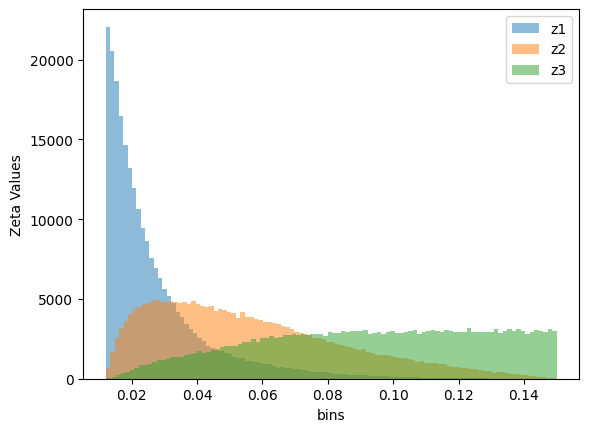

In [4]:
file = "/home/sawini-jana/hep/Paper/dataset_170.0.txt"
data = np.loadtxt(file)
z1 = data[:,0]
z2 = data[:,1]
z3 = data[:,2]
plt.hist(z1, bins=100, alpha=0.5, label="z1")
plt.hist(z2, bins=100, alpha=0.5, label="z2")
plt.hist(z3, bins=100, alpha=0.5, label="z3")
plt.xlabel("bins")
plt.ylabel("Zeta Values")
#plt.yscale("log")
plt.legend()
plt.show()

In [5]:
#Large angle separation means fewer particles
#jets are narrow cones, there higher for z1 (smaller anle)

Text(0, 0.5, 'z3')

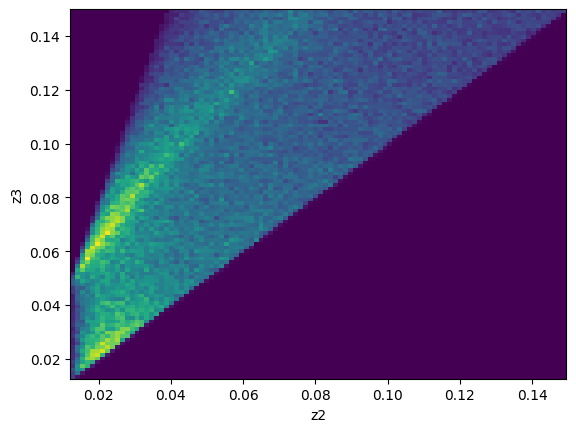

In [6]:
plt.hist2d(z2, z3, bins=100)
plt.xlabel("z2")
plt.ylabel("z3")

In [7]:
#this is an important piece of code
#only points above the diagonal exist since (z3>=z2)
#now from triangle inequality we get that z3​≤z1​+z2​≤2*z2
#the above two force the two boundary conditions

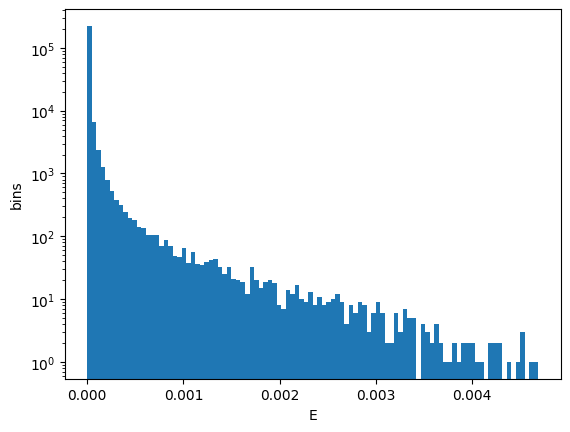

In [8]:
E_tilde = data[:,3]
plt.hist(E_tilde, bins=100)
plt.xlabel("E")
plt.ylabel("bins")
plt.yscale("log")
plt.show()

In [9]:
#SO many soft particles...

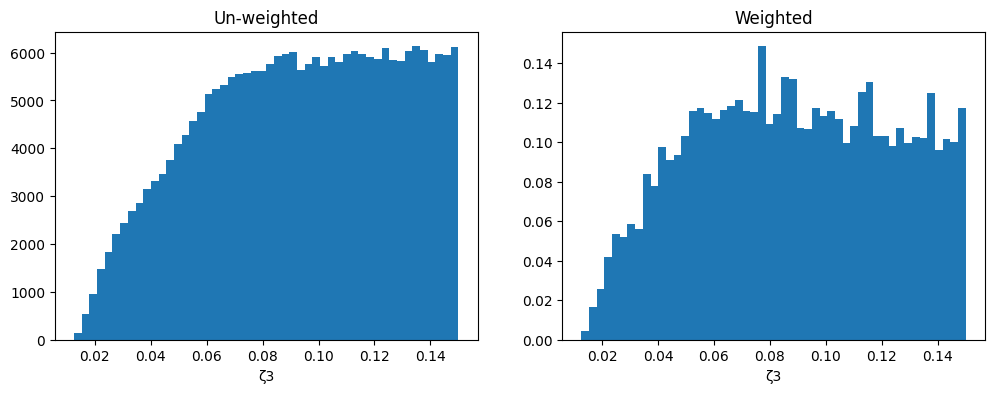

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(z3, bins=50)
axes[0].set_title("Un-weighted")
axes[0].set_xlabel("ζ3")

axes[1].hist(z3, bins=50, weights=E_tilde)
axes[1].set_xlabel("ζ3")
axes[1].set_title("Weighted")
plt.show()


In [17]:
#soft particle energies get suppressed
#at angular separation 0.07 i think we have the most energetic particles

### Figure 4a from paper

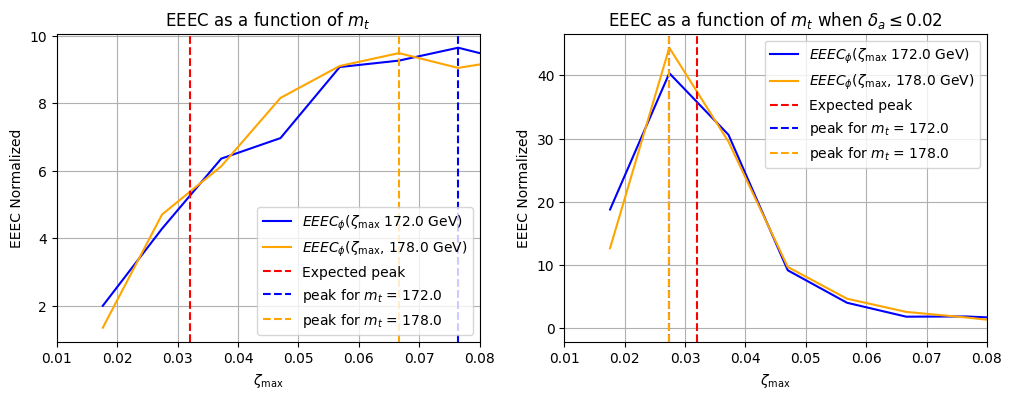

Peak at z_max = 0.0274
Peak at z_max = 0.0274


In [35]:
#Figure 4a
#zeta3 is zeta_max
file1 = "/home/sawini-jana/hep/Paper/dataset_172.0.txt"
data1 = np.loadtxt(file1)
file2 = "/home/sawini-jana/hep/Paper/dataset_178.0.txt"
data2 = np.loadtxt(file2)

zmax_1 = data1[:,2]
zmax_2 = data2[:,2]
eeec_1 = data1[:,3]
eeec_2 = data2[:,3]

zmin = min(zmax_1.min(), zmax_2.min())
zmax = max(zmax_1.max(), zmax_2.max())

bins = np.linspace(zmin, zmax, 15)

centers = 0.5*(bins[:-1] + bins[1:])

# empty histogram
hist1 = np.zeros(len(centers))
hist2 = np.zeros(len(centers))

zmax_1 = data1[:,2]
zmax_2 = data2[:,2]

# fill histogram
for i in range(len(centers)):

    mask1 = (zmax_1 >= bins[i]) & (zmax_1 < bins[i+1])
    mask2 = (zmax_2 >= bins[i]) & (zmax_2 < bins[i+1])

    hist1[i] = eeec_1[mask1].sum()
    hist2[i] = eeec_2[mask2].sum()

hist1 /= np.trapezoid(hist1, centers)
hist2 /= np.trapezoid(hist2, centers)

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(centers, hist1, color="blue", label=fr"$EEEC_\phi(\zeta_{{\max}}$ {data1[:,4][0]} GeV)")
ax[0].plot(centers, hist2, color="orange", label=fr"$EEEC_\phi(\zeta_{{\max}}$, {data2[:,4][0]} GeV)")
ax[0].axvline(0.032, color='r', linestyle='--', label='Expected peak')
ax[0].axvline(centers[np.argmax(hist1)], color='blue', linestyle='--', label=f'peak for $m_t$ = {data1[:,4][0]}')
ax[0].axvline(centers[np.argmax(hist2)], color='orange', linestyle='--', label=f'peak for $m_t$ = {data2[:,4][0]}')
ax[0].set_ylabel("EEEC Normalized")
ax[0].set_xlabel(r"$\zeta_{\max}$")
ax[0].set_title(r"EEEC as a function of $m_t$")
ax[0].legend()
ax[0].set_xlim(0.01,0.08)
ax[0].grid()

# empty histogram
hist1 = np.zeros(len(centers))
hist2 = np.zeros(len(centers))

#delta_a condition
delta_a_1 = data1[:,2] - data1[:,0]
delta_a_2 = data2[:,2] - data2[:,0]

eq1 = delta_a_1 <= 0.02
eq2 = delta_a_2 <= 0.02

zmax_1 = data1[:,2][eq1]
zmax_2 = data2[:,2][eq2]

eeec_1 = data1[:,3][eq1]
eeec_2 = data2[:,3][eq2]

# fill histogram
for i in range(len(centers)):

    mask1 = (zmax_1 >= bins[i]) & (zmax_1 < bins[i+1])
    mask2 = (zmax_2 >= bins[i]) & (zmax_2 < bins[i+1])

    hist1[i] = eeec_1[mask1].sum()
    hist2[i] = eeec_2[mask2].sum()

hist1 /= np.trapezoid(hist1, centers)
hist2 /= np.trapezoid(hist2, centers)

ax[1].plot(centers, hist1, color="blue", label=fr"$EEEC_\phi(\zeta_{{\max}}$ {data1[:,4][0]} GeV)")
ax[1].plot(centers, hist2, color="orange", label=fr"$EEEC_\phi(\zeta_{{\max}}$, {data2[:,4][0]} GeV)")
ax[1].axvline(0.032, color='r', linestyle='--', label='Expected peak')
ax[1].axvline(centers[np.argmax(hist1)], color='blue', linestyle='--', label=f'peak for $m_t$ = {data1[:,4][0]}')
ax[1].axvline(centers[np.argmax(hist2)], color='orange', linestyle='--', label=f'peak for $m_t$ = {data2[:,4][0]}')
ax[1].set_ylabel("EEEC Normalized")
ax[1].set_xlabel(r"$\zeta_{\max}$")
ax[1].set_title(r"EEEC as a function of $m_t$ when ${\delta_a} \leq 0.02$")
ax[1].legend()
ax[1].set_xlim(0.01,0.08)
ax[1].grid()

plt.show()

# Also print where the maximum is:
print(f"Peak at z_max = {centers[np.argmax(hist1)]:.4f}")
print(f"Peak at z_max = {centers[np.argmax(hist2)]:.4f}")

In [20]:
#for mt = 178.0 GeV
zp = z1 + z2 + z3
z1.mean(), z2.mean(), z3.mean(), zp.mean(), zp.mean()/z3.mean(), zp.max()/z3.max()

(np.float64(0.027330318248757722),
 np.float64(0.05630774700656527),
 np.float64(0.09320671832730573),
 np.float64(0.17684478358262873),
 np.float64(1.8973394488755484),
 np.float64(2.9569060920812276))

In [21]:
#for mt= 178.0 GeV
delta_a = z3 - z1
mask = delta_a <= 0.02
# Check if filtered triangles are actually equilateral:
print(f"After filter:")
print(f"z1 mean: {z1[mask].mean():.4f}")
print(f"z2 mean: {z2[mask].mean():.4f}")
print(f"z3 mean: {z3[mask].mean():.4f}")
print(f"z3-z1 mean: {(z3[mask]-z1[mask]).mean():.4f}")

After filter:
z1 mean: 0.0277
z2 mean: 0.0333
z3 mean: 0.0399
z3-z1 mean: 0.0122


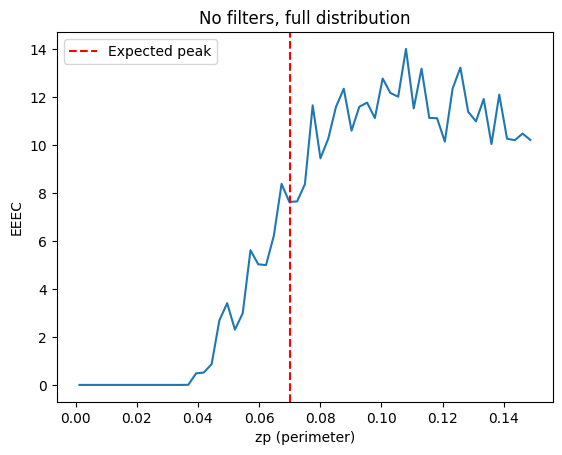

Peak at zp = 0.1081


In [22]:
data = np.loadtxt("/home/sawini-jana/hep/Paper/dataset_170.5.txt")
z1, z2, z3 = data[:,0], data[:,1], data[:,2]
E_tilde = data[:,3]
zp = z1 + z2 + z3

# Full range, no filter:
bins = np.linspace(0.00, 0.15, 60)
centers = 0.5*(bins[:-1]+bins[1:])

counts, _ = np.histogram(zp, bins=bins, weights=E_tilde)
norm = np.trapezoid(counts, centers)
counts /= norm

plt.figure()
plt.plot(centers, counts)
plt.xlabel("zp (perimeter)")
plt.ylabel("EEEC")
plt.title("No filters, full distribution")
plt.axvline(0.07, color='r', linestyle='--', label='Expected peak')
plt.legend()
plt.show()

# Also print where the maximum is:
print(f"Peak at zp = {centers[np.argmax(counts)]:.4f}")

In [23]:
#zeta_max is basically zeta3
max(data1[:,2]), max(data2[:,2])

(np.float64(0.149998), np.float64(0.15))

In [24]:
min(z1 + z2 + z3), max(z1 + z2 + z3)

(np.float64(0.0374428), np.float64(0.439661))

### Figure 2 from paper

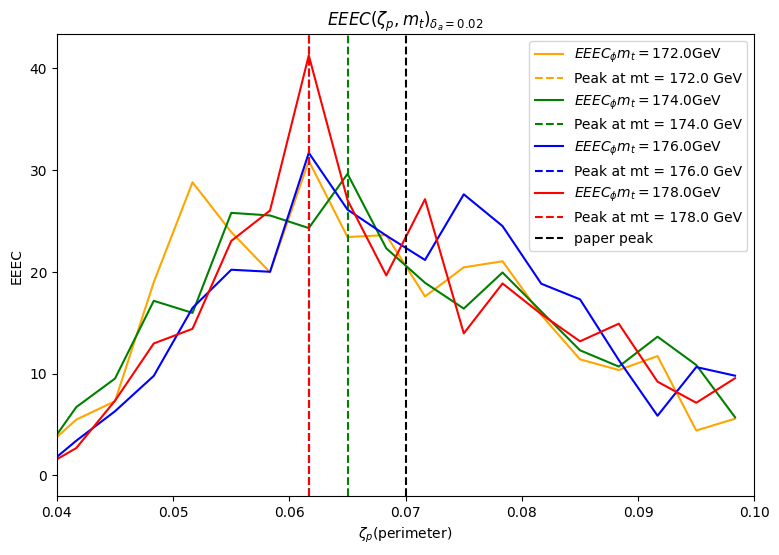

In [50]:
mass = [172.0, 174.0, 176.0, 178.0]
bins = np.linspace(0.02, 0.10, 25)
centers = 0.5 * (bins[:-1] + bins[1:])

t= 0
colour = ["orange", "green", "blue", "red"]
plt.figure(figsize=(9,6))
for m in mass:
    file = "/home/sawini-jana/hep/Paper/dataset_"+ str(m)+".txt"
    data = np.loadtxt(file)
    E_tilde = data[:,3]
    z1,z2,z3 = data[:,0], data[:,1], data[:,2]
    zp = z1 + z2 + z3
    delta_a = z3-z1
    mask = delta_a <=0.02
    eeec_mc = np.zeros(len(centers))

    for q in range(len(centers)):
        mask_bin = ((zp >= bins[q]) &(zp < bins[q+1]) & mask)
        eeec_mc[q] = E_tilde[mask_bin].sum()

    eeec_mc /= np.trapezoid(eeec_mc, centers)

    plt.plot(centers,eeec_mc,label=rf'$EEEC_{{\phi}} m_t= {m}$GeV',color = colour[t])
    plt.axvline(centers[np.argmax(eeec_mc)], color=colour[t], linestyle='--', label=f'Peak at mt = {m} GeV')
    t += 1

#plt.ylim(0,50)
plt.title(r'$EEEC(\zeta_p, m_t)_{\delta_a=0.02}$')
plt.ylabel('EEEC')
plt.axvline(0.07, color='black', linestyle='--', label='paper peak')
plt.xlabel(r'$\zeta_{p}$(perimeter)')
plt.xlim(0.04,0.10)
plt.legend()
plt.show()

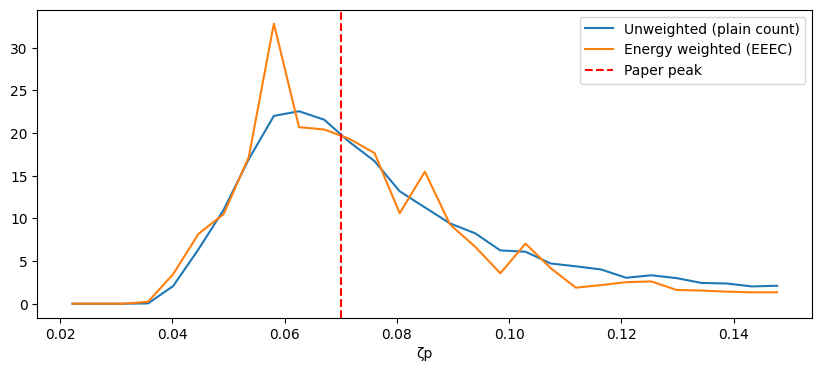

Unweighted peak:     0.0626
Energy weighted peak:0.0581


In [47]:
data = np.loadtxt("/home/sawini-jana/hep/Paper/dataset_170.0.txt")
z1, z2, z3 = data[:,0], data[:,1], data[:,2]
E_tilde = data[:,3]
zp = z1 + z2 + z3
delta_a = z3 - z1
mask = delta_a <= 0.02

bins = np.linspace(0.02, 0.15, 30)
centers = 0.5*(bins[:-1]+bins[1:])

# Unweighted:
counts_plain, _ = np.histogram(zp[mask], bins=bins)
counts_plain = counts_plain / np.trapezoid(counts_plain, centers)

# Energy weighted:
counts_weighted, _ = np.histogram(zp[mask], bins=bins, weights=E_tilde[mask])
counts_weighted = counts_weighted / np.trapezoid(counts_weighted, centers)

plt.figure(figsize=(10,4))
plt.plot(centers, counts_plain,    label='Unweighted (plain count)')
plt.plot(centers, counts_weighted, label='Energy weighted (EEEC)')
plt.axvline(0.07, color='r', linestyle='--', label='Paper peak')
plt.xlabel("ζp")
plt.legend()
plt.show()

print(f"Unweighted peak:     {centers[np.argmax(counts_plain)]:.4f}")
print(f"Energy weighted peak:{centers[np.argmax(counts_weighted)]:.4f}")

Fraction with δa≤0.02: 0.087


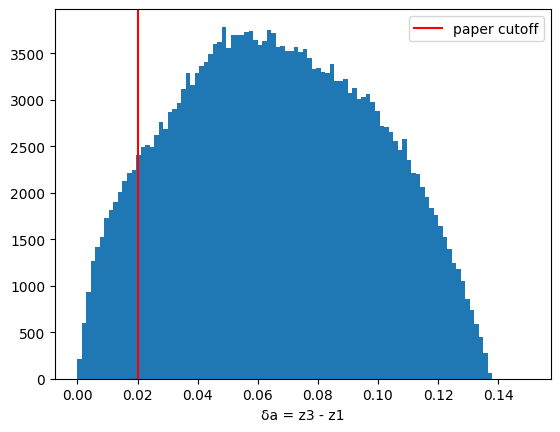

In [27]:
data = np.loadtxt("/home/sawini-jana/hep/Paper/dataset_170.0.txt")
z1, z2, z3 = data[:,0], data[:,1], data[:,2]
delta_a = z3 - z1

# What fraction survives δa≤0.02?
print(f"Fraction with δa≤0.02: {(delta_a<=0.02).mean():.3f}")

# Plot delta_a distribution:
plt.hist(delta_a, bins=100, range=(0, 0.15))
plt.xlabel("δa = z3 - z1")
plt.axvline(0.02, color='r', label='paper cutoff')
plt.legend()
plt.show()

In [28]:
mask_paper = delta_a <= 0.02   # paper's cut

zp = z1 + z2 + z3

print(f"ζp mean (δa≤0.020): {zp[mask_paper].mean():.4f}")
print(f"ζmax mean (δa≤0.020): {z3[mask_paper].mean():.4f}")
print(f"Ratio ζp/ζmax (δa≤0.020): {zp[mask_paper].mean()/z3[mask_paper].mean():.2f}")

ζp mean (δa≤0.020): 0.1009
ζmax mean (δa≤0.020): 0.0399
Ratio ζp/ζmax (δa≤0.020): 2.53


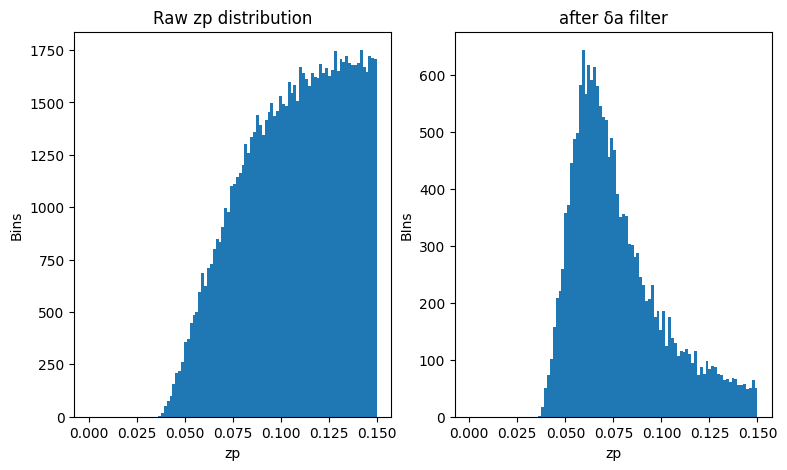

In [29]:
plt.figure(figsize=(9,5))
plt.subplot(1,2,1)
plt.hist(zp, bins=100, range=(0, 0.15))
plt.xlabel("zp")
plt.ylabel("Bins")
plt.title("Raw zp distribution")

# Also check after delta_a filter:
delta_a = z3 - z1
mask = delta_a <= 0.02
plt.subplot(1,2,2)
plt.ylabel("BIns")
plt.title("after δa filter")
plt.hist(zp[mask], bins=100, range=(0, 0.15))
plt.xlabel("zp")
plt.show()